# Linear Regression (Fixed)

I added comments showing the mistakes and fixes.

In [1]:
import numpy as np

class LinearRegression:
    def __init__(self, lr=0.001, n_iters=1000):
        self.lr = lr
        self.n_iters = n_iters
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iters):

            # Predictions
            y_predicted = np.dot(X, self.weights) + self.bias

            # Gradients
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            # MISTAKE IN ORIGINAL:
            # self.weights -= self.lr + dw
            #
            # This performs:
            # w = w - (lr + dw)
            #
            # Gradient Descent should be:
            # w = w - lr * dw
            self.weights -= self.lr * dw

            self.bias -= self.lr * db

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias


In [2]:
from sklearn.model_selection import train_test_split
from sklearn import datasets
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

X, y = datasets.make_regression(
    n_samples=100,
    n_features=1,
    noise=20,
    random_state=4
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=1234
)

regressor = LinearRegression()
regressor.fit(X_train, y_train)

pred = regressor.predict(X_test)

print("MSE:", mean_squared_error(y_test, pred))


MSE: 783.815546512549


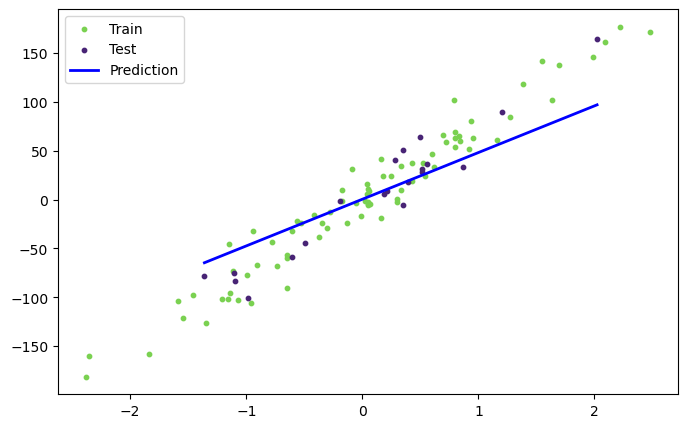

In [3]:
# MISTAKE IN ORIGINAL PLOT:
#
# plt.plot(X_test, pred)
#
# X_test is shuffled after train_test_split.
# Matplotlib connects points in that shuffled order,
# producing a zig-zag line.
#
# Fix: sort X before plotting.

cmap = plt.get_cmap("viridis")

plt.figure(figsize=(8, 5))

plt.scatter(X_train, y_train, color=cmap(0.8), s=10, label="Train")
plt.scatter(X_test, y_test, color=cmap(0.1), s=10, label="Test")

sorted_idx = np.argsort(X_test[:, 0])

plt.plot(
    X_test[sorted_idx],
    pred[sorted_idx],
    color="blue",
    linewidth=2,
    label="Prediction"
)

plt.legend()
plt.show()
